### Red Neuronal SOM

#### SON: Self Organizing Maps - KOHONEN

#### Optimización de una paleta de colores para un sistema gráfico

In [26]:
!pip install minisom 

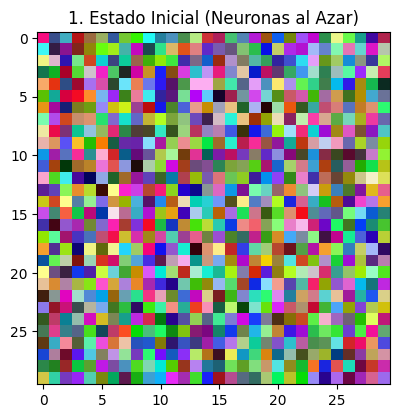

In [27]:
import numpy as np
import matplotlib.pyplot as plt

from minisom import MiniSom

np.random.seed(42)

datos_colores = np.random.rand(3000, 3)

# Cuadrícula de 30x30
tamano_x = 30
tamano_y = 30

som = MiniSom(
    tamano_x,
    tamano_y,
    3,
    sigma=3.0,
    learning_rate=0.5
)

som.random_weights_init(datos_colores)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("1. Estado Inicial (Neuronas al Azar)")
plt.imshow(som.get_weights())

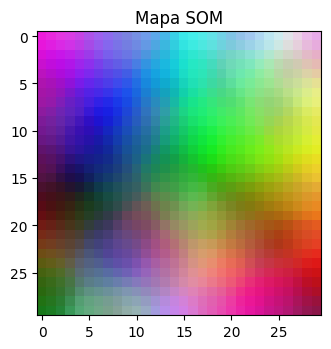

In [28]:
# Entrenar la red
som.train_random(
    datos_colores,
30000
)

# Mostrar el estado final
plt.subplot(1, 2, 2)
plt.title("Mapa SOM")
plt.imshow(som.get_weights())

plt.tight_layout()
plt.show()

In [29]:
# Caso RFM con una Red SOM

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from minisom import MiniSom
from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.mplot3d import Axes3D

In [35]:
# Ruta corregida con raw string (evita que Python interprete \U, \p, etc. como escapes)
ruta_clientes = r"dataset_SOM.xlsx"

df_clientes = pd.read_excel(ruta_clientes)

display(df_clientes)

,Recencia_Dias,Frecuencia_Semanal,Gasto_Promedio,Uso_Descuentos
0,75.553184,0.319784,43.439459,25.526450
1,3.983115,6.054010,127.245935,10.296509
2,71.283276,0.137565,28.826940,31.283447
3,12.087373,2.662964,25.796198,90.276212
4,4.617521,5.330605,100.968996,11.002392
...,...,...,...,...
495,1.684460,4.733766,112.205383,9.639909
496,15.979450,2.186485,27.171291,85.789541
497,13.764887,2.074552,18.940682,76.069701
498,74.736497,0.326978,46.047618,29.493110


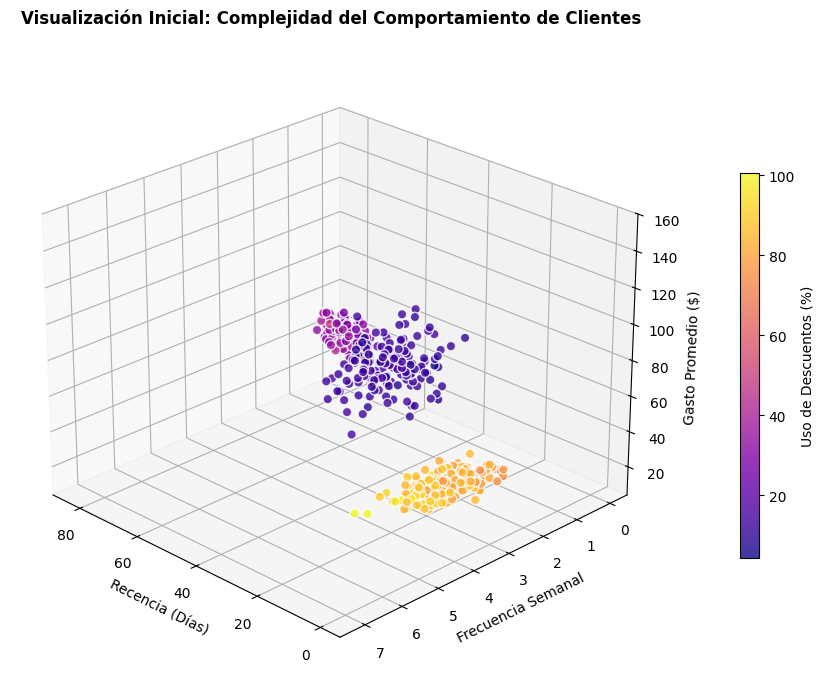

In [36]:
#Visualizacion de los datos


fig = plt.figure(figsize=(9, 7))

ax = fig.add_subplot(
    111,
    projection="3d"
)

scatter = ax.scatter(
    df_clientes["Recencia_Dias"],
    df_clientes["Frecuencia_Semanal"],
    df_clientes["Gasto_Promedio"],
    c=df_clientes["Uso_Descuentos"],  # Cuarta variable mapeada en el color
    cmap="plasma",
    s=45,
    alpha=0.8,
    edgecolors="w"
)

ax.set_title(
    "Visualización Inicial: Complejidad del Comportamiento de Clientes",
    fontsize=12,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Recencia (Días)")
ax.set_ylabel("Frecuencia Semanal")
ax.set_zlabel("Gasto Promedio ($)")

fig.colorbar(
    scatter,
    ax=ax,
    label="Uso de Descuentos (%)",
    shrink=0.6,
    pad=0.1
)

ax.view_init(
    elev=25,
    azim=135
)

plt.tight_layout()
plt.show()

In [38]:
#Escalado y configuración SOM

scaler =MinMaxScaler()

datos_escalados = scaler.fit_transform(df_clientes)

#Modelado de la RED
#Definición del tamaño de la ciadricula 20x20
tamano_x = 20
tamano_y = 20
dimension_Entrada = 4

som = MiniSom(tamano_x, tamano_y, dimension_Entrada, sigma=2.5, learning_rate=0.5, random_seed=42)
som.random_weights_init(datos_escalados)

#Entramient de la red

print("\nEntrenando la red...")
som.train_random(datos_escalados, 3000)
print("Entramiento finalizado")


Entrenando la red...
Entramiento finalizado


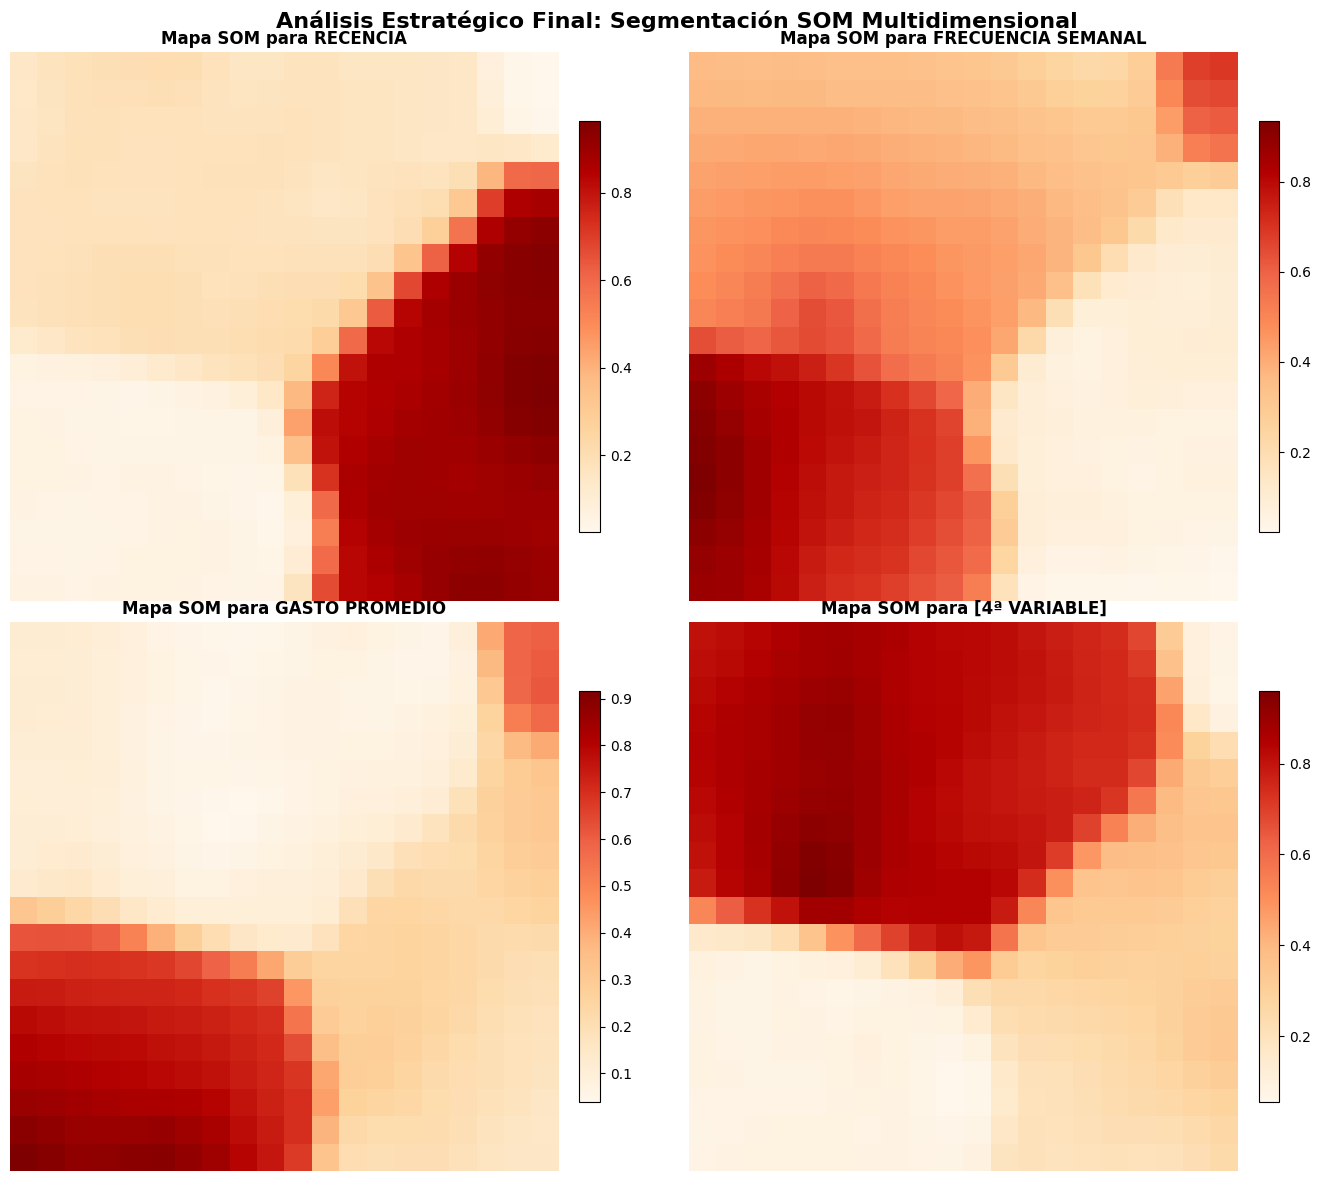

In [49]:
# === Visualización final ===

pesos = som.get_weights()  # forma: (x, y, n_variables)

# Cuadrícula 2x2 para mostrar las 4 variables del negocio trasladadas a 2 dimensiones
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()  # aplanamos la matriz de subplots para iterar con un único índice

titulos = [
    "Mapa SOM para RECENCIA",
    "Mapa SOM para FRECUENCIA SEMANAL",
    "Mapa SOM para GASTO PROMEDIO",
    "Mapa SOM para [4ª VARIABLE]",  # ajusta el nombre real de tu 4ª variable
]


for i, ax in enumerate(axes):
    capa_variable = pesos[:, :, i]

    # Renderizamos cada plano
    im = ax.imshow(
        capa_variable,
        cmap="OrRd",
        origin="lower"
    )

    ax.set_title(
        titulos[i],
        fontsize=12,
        fontweight="bold"
    )

    ax.axis("off")

    fig.colorbar(
        im,
        ax=ax,
        orientation="vertical",
        shrink=0.75,
        pad=0.03
    )

plt.suptitle(
    "Análisis Estratégico Final: Segmentación SOM Multidimensional",
    fontsize=16,
    fontweight="bold",
    y=0.98
)

plt.tight_layout()
plt.show()
